In [1]:
# ==============================================================================
# CELL 1: SETUP & LOAD DATA
# ==============================================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

FOLDER_UTAMA  = r"D:\Collage\AnuJurnal"
FOLDER_GAMBAR = r"D:\Collage\AnuJurnal\Gambar Hasil"
os.makedirs(FOLDER_GAMBAR, exist_ok=True)

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.4,
})

WARNA_FOMC = '#2563EB'   # Biru tua → FinBERT-FOMC

# Load FinBERT-FOMC
path_fomc  = os.path.join(FOLDER_UTAMA, '03_hasil_finbert_klasifikasi.csv')
df_fomc    = pd.read_csv(path_fomc, sep=';')
label_fomc = df_fomc['Sentimen_Aktual']
pred_fomc  = df_fomc['Prediksi_Sentimen']

acc_fomc = accuracy_score(label_fomc, pred_fomc)

kelas_negatif = 'Negatif (Hawkish)'
kelas_positif = 'Positif (Dovish)'

metrics_fomc = {
    'Precision-Neg': precision_score(label_fomc, pred_fomc, pos_label=kelas_negatif),
    'Precision-Pos': precision_score(label_fomc, pred_fomc, pos_label=kelas_positif),
    'Recall-Neg'   : recall_score(label_fomc, pred_fomc, pos_label=kelas_negatif),
    'Recall-Pos'   : recall_score(label_fomc, pred_fomc, pos_label=kelas_positif),
    'F1-Neg'       : f1_score(label_fomc, pred_fomc, pos_label=kelas_negatif),
    'F1-Pos'       : f1_score(label_fomc, pred_fomc, pos_label=kelas_positif),
    'Macro-F1'     : f1_score(label_fomc, pred_fomc, average='macro'),
}

print('✅ Data berhasil dimuat!')
print(f'   → FinBERT-FOMC  Akurasi: {acc_fomc*100:.2f}%')


✅ Data berhasil dimuat!
   → FinBERT-FOMC  Akurasi: 64.58%


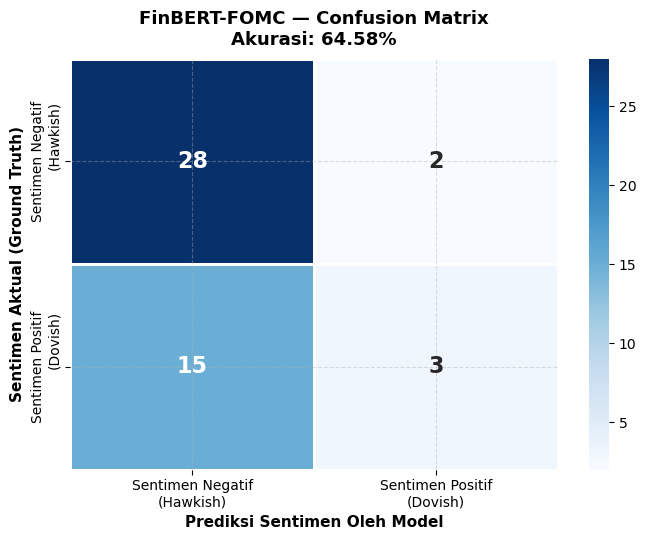

✅ Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\01_Confusion_Matrix_FinBERT_FOMC.png


In [2]:
# ==============================================================================
# GAMBAR 1: CONFUSION MATRIX — FINBERT-FOMC
# ==============================================================================

label_order = ['Negatif (Hawkish)', 'Positif (Dovish)']
cm_fomc = confusion_matrix(label_fomc, pred_fomc, labels=label_order)
klabel  = ['Sentimen Negatif\n(Hawkish)', 'Sentimen Positif\n(Dovish)']

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm_fomc, annot=True, fmt='d', cmap='Blues',
    xticklabels=klabel, yticklabels=klabel,
    annot_kws={'size': 16, 'weight': 'bold'},
    linewidths=1, linecolor='white', ax=ax
)
ax.set_title(f'FinBERT-FOMC — Confusion Matrix\nAkurasi: {acc_fomc*100:.2f}%',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Prediksi Sentimen Oleh Model', fontsize=11, fontweight='bold')
ax.set_ylabel('Sentimen Aktual (Ground Truth)', fontsize=11, fontweight='bold')

plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '01_Confusion_Matrix_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {path_g}')


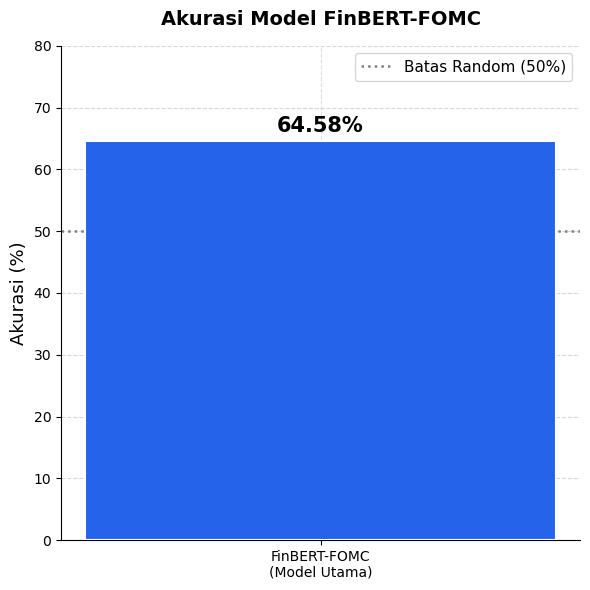

✅ Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\02_Accuracy_FinBERT_FOMC.png


In [3]:
# ==============================================================================
# GAMBAR 2: ACCURACY — FINBERT-FOMC
# ==============================================================================

fig, ax = plt.subplots(figsize=(6, 6))

bar = ax.bar(['FinBERT-FOMC\n(Model Utama)'], [acc_fomc * 100],
             color=[WARNA_FOMC], width=0.35, edgecolor='white', linewidth=1.5, zorder=3)

ax.text(bar[0].get_x() + bar[0].get_width() / 2,
        bar[0].get_height() + 0.8,
        f'{acc_fomc*100:.2f}%',
        ha='center', va='bottom', fontsize=15, fontweight='bold')

ax.axhline(y=50, color='gray', linestyle=':', linewidth=1.8, label='Batas Random (50%)')
ax.set_ylim(0, 80)
ax.set_ylabel('Akurasi (%)', fontsize=13)
ax.set_title('Akurasi Model FinBERT-FOMC', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '02_Accuracy_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {path_g}')


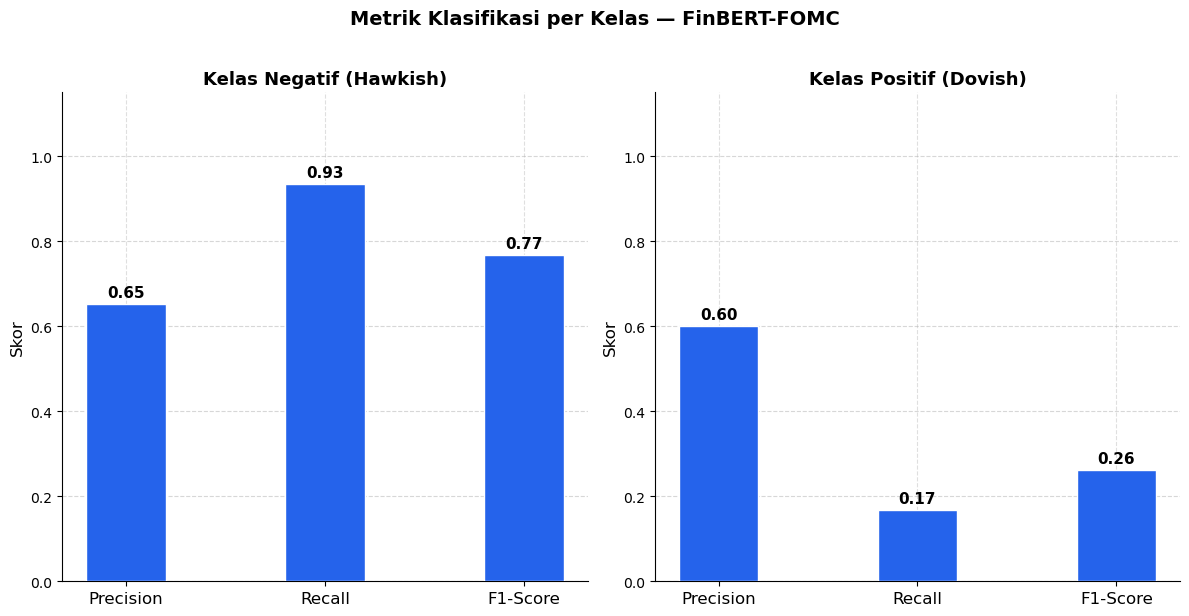

✅ Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\03_Precision_Recall_F1_FinBERT_FOMC.png


In [4]:
# ==============================================================================
# GAMBAR 3: PRECISION / RECALL / F1 — FINBERT-FOMC
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=False)
fig.suptitle('Metrik Klasifikasi per Kelas — FinBERT-FOMC',
             fontsize=14, fontweight='bold', y=1.02)

metrik_nama = ['Precision', 'Recall', 'F1-Score']
x     = np.arange(len(metrik_nama))
lebar = 0.40

for ax, suffix, kelas_nama in zip(axes,
                                   ['Neg', 'Pos'],
                                   ['Negatif (Hawkish)', 'Positif (Dovish)']):
    vals = [metrics_fomc[f'Precision-{suffix}'],
            metrics_fomc[f'Recall-{suffix}'],
            metrics_fomc[f'F1-{suffix}']]

    bars = ax.bar(x, vals, lebar, color=WARNA_FOMC, edgecolor='white', zorder=3)

    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() + 0.01,
                f'{b.get_height():.2f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylim(0, 1.15)
    ax.set_xticks(x)
    ax.set_xticklabels(metrik_nama, fontsize=12)
    ax.set_ylabel('Skor', fontsize=12)
    ax.set_title(f'Kelas {kelas_nama}', fontsize=13, fontweight='bold')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '03_Precision_Recall_F1_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {path_g}')


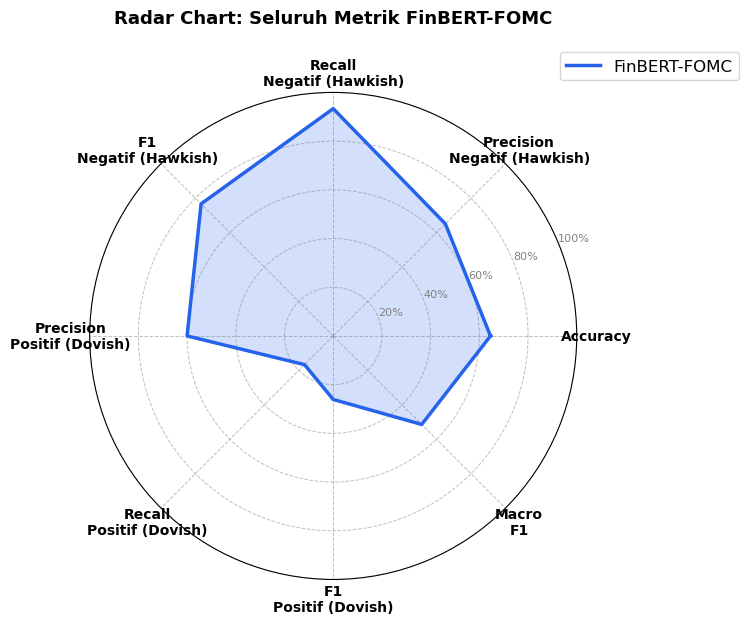

✅ Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\04_Radar_Chart_FinBERT_FOMC.png


In [5]:
# ==============================================================================
# GAMBAR 4: RADAR CHART — FINBERT-FOMC
# ==============================================================================

kategori = ['Accuracy',
            'Precision\nNegatif (Hawkish)', 'Recall\nNegatif (Hawkish)', 'F1\nNegatif (Hawkish)',
            'Precision\nPositif (Dovish)',  'Recall\nPositif (Dovish)',  'F1\nPositif (Dovish)',
            'Macro\nF1']

nilai_fomc = [
    acc_fomc,
    metrics_fomc['Precision-Neg'], metrics_fomc['Recall-Neg'], metrics_fomc['F1-Neg'],
    metrics_fomc['Precision-Pos'], metrics_fomc['Recall-Pos'], metrics_fomc['F1-Pos'],
    metrics_fomc['Macro-F1'],
]

N      = len(kategori)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]
vals   = nilai_fomc + [nilai_fomc[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
ax.plot(angles, vals, color=WARNA_FOMC, linewidth=2.5, label='FinBERT-FOMC')
ax.fill(angles, vals, color=WARNA_FOMC, alpha=0.20)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(kategori, fontsize=10, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=8, color='gray')
ax.grid(color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
ax.set_title('Radar Chart: Seluruh Metrik FinBERT-FOMC',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=12)

plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '04_Radar_Chart_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {path_g}')


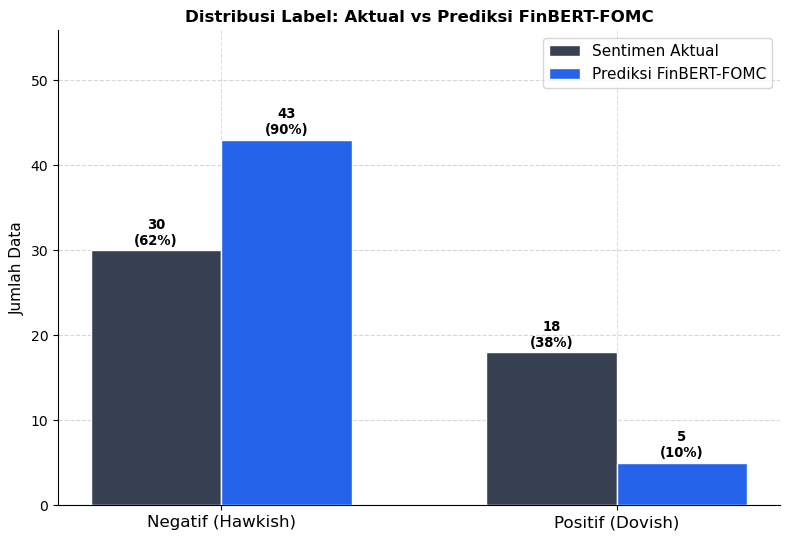

✅ Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\05_Distribusi_Label_FinBERT_FOMC.png


In [6]:
# ==============================================================================
# GAMBAR 5: DISTRIBUSI LABEL — AKTUAL vs PREDIKSI FINBERT-FOMC
# ==============================================================================

fig, ax = plt.subplots(figsize=(8, 5.5))

klabel   = ['Negatif (Hawkish)', 'Positif (Dovish)']
cnt_asli = [np.sum(label_fomc == 'Negatif (Hawkish)'), np.sum(label_fomc == 'Positif (Dovish)')]
cnt_pred = [np.sum(pred_fomc  == 'Negatif (Hawkish)'), np.sum(pred_fomc  == 'Positif (Dovish)')]

x, w = np.arange(2), 0.33
b1 = ax.bar(x - w/2, cnt_asli, w, label='Sentimen Aktual',
            color='#374151', edgecolor='white', zorder=3)
b2 = ax.bar(x + w/2, cnt_pred, w, label='Prediksi FinBERT-FOMC',
            color=WARNA_FOMC,  edgecolor='white', zorder=3)

total = len(label_fomc)
for bar, val in zip(list(b1) + list(b2), cnt_asli + cnt_pred):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{val}\n({val/total*100:.0f}%)',
            ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(klabel, fontsize=12)
ax.set_ylabel('Jumlah Data', fontsize=11)
ax.set_title('Distribusi Label: Aktual vs Prediksi FinBERT-FOMC',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(cnt_asli + cnt_pred) * 1.30)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '05_Distribusi_Label_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {path_g}')


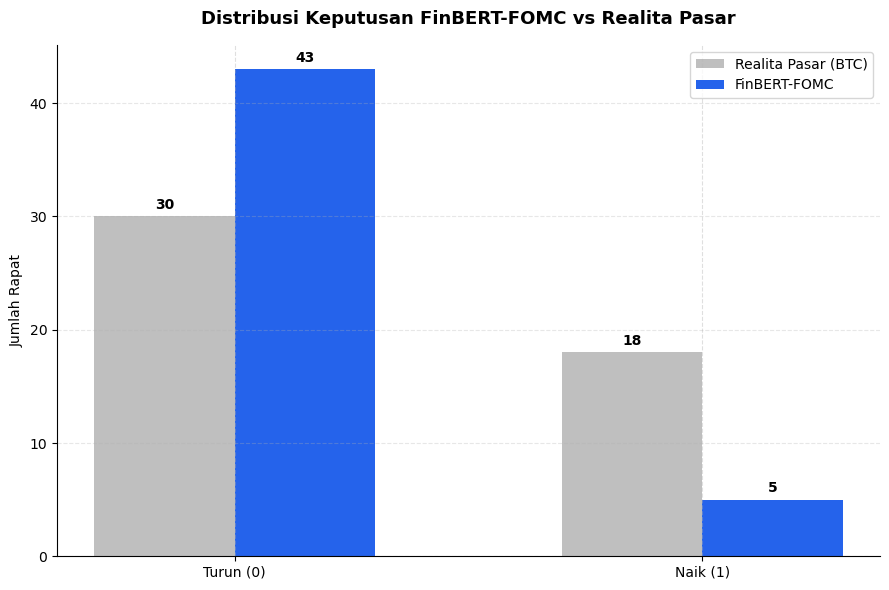

✅ Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\06_Distribusi_Keputusan_FinBERT_FOMC.png


In [7]:
# ==============================================================================
# GAMBAR 6: DISTRIBUSI KEPUTUSAN FINBERT-FOMC vs REALITA PASAR
# ==============================================================================

df_fomc_res  = pd.read_csv('03_hasil_finbert.csv', sep=';', decimal=',')
dist_fomc    = df_fomc_res['Sinyal_Prediksi'].value_counts().sort_index()
dist_realita = df_fomc_res['Label_Asli'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 6))
labels, x, width = ['Turun (0)', 'Naik (1)'], np.arange(2), 0.30

r1 = ax.bar(x - width/2, dist_realita, width,
            label='Realita Pasar (BTC)', color='gray', alpha=0.5)
r2 = ax.bar(x + width/2, dist_fomc,    width,
            label='FinBERT-FOMC', color=WARNA_FOMC)

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(str(h),
                    xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontweight='bold')

autolabel(r1)
autolabel(r2)

ax.set_ylabel('Jumlah Rapat')
ax.set_title('Distribusi Keputusan FinBERT-FOMC vs Realita Pasar',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '06_Distribusi_Keputusan_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {path_g}')


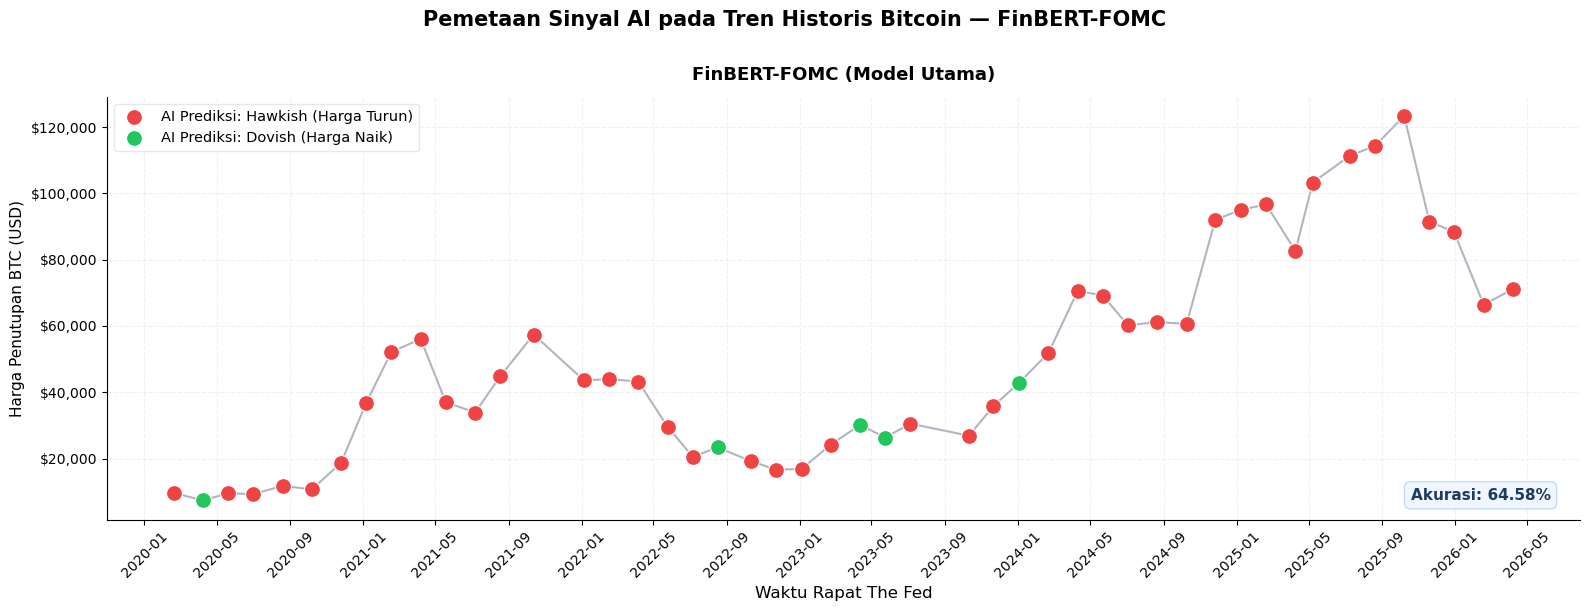

Disimpan: D:\Collage\AnuJurnal\Gambar Hasil\07_Timeline_Sinyal_FinBERT_FOMC.png


In [11]:
# ==============================================================================
# GAMBAR 7: TIMELINE SCATTER PLOT — FINBERT-FOMC
# Data harga BTC + sinyal prediksi diambil dari 03_hasil_finbert.csv
# Titik MERAH = Prediksi Hawkish (Harga Turun / Sinyal 0)
# Titik HIJAU = Prediksi Dovish  (Harga Naik  / Sinyal 1)
# ==============================================================================

import matplotlib.dates as mdates

df_tl = pd.read_csv(
    os.path.join(FOLDER_UTAMA, '03_hasil_finbert.csv'),
    sep=';', decimal=','
)
df_tl['Tanggal'] = pd.to_datetime(df_tl['Tanggal'])

tanggal  = df_tl['Tanggal'].values
harga    = df_tl['Close'].values
prediksi = df_tl['Sinyal_Prediksi'].values

def format_ribuan(x, pos):
    return '${:,.0f}'.format(x)

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Pemetaan Sinyal AI pada Tren Historis Bitcoin — FinBERT-FOMC',
             fontsize=15, fontweight='bold', y=1.01)

ax.plot(tanggal, harga, color='#9CA3AF', linewidth=1.5, zorder=1, alpha=0.8)

mask_hawkish = prediksi == 0
mask_dovish  = prediksi == 1

ax.scatter(tanggal[mask_hawkish], harga[mask_hawkish],
           color='#EF4444', s=130, zorder=5, edgecolors='white', linewidths=0.8,
           label='AI Prediksi: Hawkish (Harga Turun)')
ax.scatter(tanggal[mask_dovish],  harga[mask_dovish],
           color='#22C55E', s=130, zorder=5, edgecolors='white', linewidths=0.8,
           label='AI Prediksi: Dovish (Harga Naik)')

ax.set_title('FinBERT-FOMC (Model Utama)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Waktu Rapat The Fed', fontsize=12)
ax.set_ylabel('Harga Penutupan BTC (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(format_ribuan))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
ax.grid(True, linestyle='--', alpha=0.35, color='#D1D5DB')
ax.set_facecolor('white')
ax.legend(loc='upper left', fontsize=10.5, framealpha=0.92, edgecolor='#E5E7EB')
ax.text(0.98, 0.04, 'Akurasi: {:.2f}%'.format(acc_fomc * 100),
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=11, fontweight='bold', color='#1E3A5F',
        bbox=dict(facecolor='#EFF6FF', edgecolor='#BFDBFE',
                  boxstyle='round,pad=0.4', alpha=0.95))

plt.xticks(rotation=45)
plt.tight_layout()
path_g = os.path.join(FOLDER_GAMBAR, '07_Timeline_Sinyal_FinBERT_FOMC.png')
plt.savefig(path_g, dpi=300, bbox_inches='tight')
plt.show()
print('Disimpan: ' + path_g)


In [12]:
# ==============================================================================
# RINGKASAN AKHIR — TABEL METRIK FINBERT-FOMC
# ==============================================================================

tabel = pd.DataFrame({
    'Metrik': [
        'Accuracy',
        'Precision — Negatif (Hawkish)', 'Recall — Negatif (Hawkish)', 'F1-Score — Negatif (Hawkish)',
        'Precision — Positif (Dovish)',  'Recall — Positif (Dovish)',  'F1-Score — Positif (Dovish)',
        'Macro F1-Score',
    ],
    'FinBERT-FOMC': [
        f"{acc_fomc*100:.2f}%",
        f"{metrics_fomc['Precision-Neg']:.2f}",
        f"{metrics_fomc['Recall-Neg']:.2f}",
        f"{metrics_fomc['F1-Neg']:.2f}",
        f"{metrics_fomc['Precision-Pos']:.2f}",
        f"{metrics_fomc['Recall-Pos']:.2f}",
        f"{metrics_fomc['F1-Pos']:.2f}",
        f"{metrics_fomc['Macro-F1']:.2f}",
    ],
})

path_tabel = os.path.join(FOLDER_GAMBAR, '08_Tabel_Metrik_FinBERT_FOMC.csv')
tabel.to_csv(path_tabel, index=False, sep=';')

print('\n' + '='*60)
print('RINGKASAN EVALUASI FINAL — FinBERT-FOMC')
print('='*60)
display(tabel)
print(f'\n✅ SEMUA GAMBAR (7 PNG + 1 CSV) berhasil diekspor ke:')
print(f'   {FOLDER_GAMBAR}')



RINGKASAN EVALUASI FINAL — FinBERT-FOMC


,Metrik,FinBERT-FOMC
0,Accuracy,64.58%
1,Precision — Negatif (Hawkish),0.65
2,Recall — Negatif (Hawkish),0.93
3,F1-Score — Negatif (Hawkish),0.77
4,Precision — Positif (Dovish),0.60
5,Recall — Positif (Dovish),0.17
6,F1-Score — Positif (Dovish),0.26
7,Macro F1-Score,0.51



✅ SEMUA GAMBAR (7 PNG + 1 CSV) berhasil diekspor ke:
   D:\Collage\AnuJurnal\Gambar Hasil
